In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import time
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings("ignore")


In [2]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [4]:
start_program = time.time()
photos_csv = r"D:\AI and Data Science- Loyalist College\Term 3\Computer Vision\Assignment 1\photos"
photos_folder = r"D:\AI and Data Science- Loyalist College\Term 3\Computer Vision\Assignment 1\photos"
# Load dataset
df = pd.read_csv(photos_csv)

In [20]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


In [22]:
df=df[['photo_id','label']]

In [24]:
df

,photo_id,label
0,zsvj7vloL4L5jhYyPIuVwg,inside
1,HCUdRJHHm_e0OCTlZetGLg,outside
2,vkr8T0scuJmGVvN2HJelEA,drink
3,pve7D6NUrafHW3EAORubyw,food
4,H52Er-uBg6rNrHcReWTD2w,food
...,...,...
200095,4Zia9NkAfQNjMfcIDhwJ-g,food
200096,KB96KRZRhRm8hUkI-OpGEA,inside
200097,Klmojvaf2_2dP1XKzTsFmQ,food
200098,FNEiq7Mogec7t31OaU5juw,drink


DATA PREPROCESSING

In [28]:
def bar_plot(data):
    class_counts = pd.Series(data).value_counts()

    # Plot bar chart
    class_counts.plot(kind="bar", color=["green", "red", "blue", "orange", "yellow"], edgecolor="black", figsize=(8, 6))

    # Add values on top of each bar
    for i, v in enumerate(class_counts):
        plt.text(i, v + 0.2, str(v), ha="center", fontsize=12)
        
        
    print("class_count : ", class_counts)
    # Customize plot
    plt.xlabel("Sentiment Labels")
    plt.ylabel("Frequency")
    plt.title("Sentiment Distribution in Traget ")
    plt.xticks(rotation=0)  # Keep labels readable
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the plot
    plt.show()

class_count :  label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64


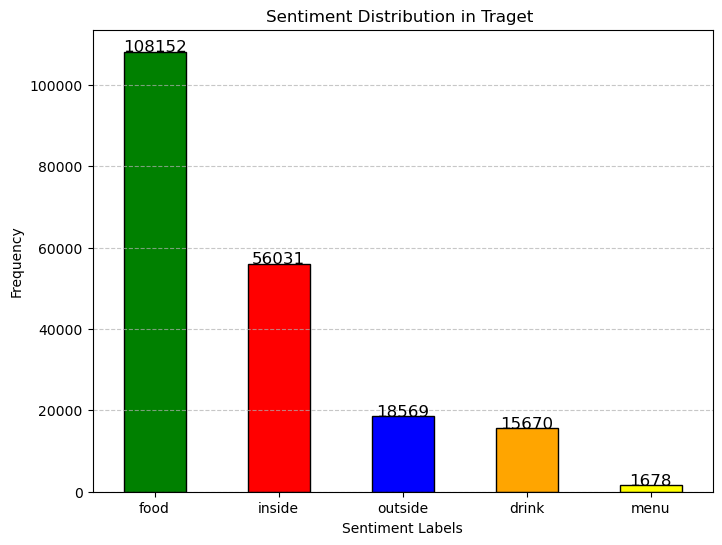

In [30]:
bar_plot(df['label'])

BALANCING THE DATASET

In [34]:
# Separate majority and minority classes
df_majority_food = df[df['label'] == 'food']
df_majority_inside = df[df['label'] == 'inside']
df_majority_outside = df[df['label'] == 'outside']
df_majority_drink = df[df['label'] == 'drink']
df_minority_menu = df[df['label'] == 'menu']

# Undersample majority classes to 600 samples each
df_majority_food_downsampled = resample(df_majority_food, replace=False, n_samples=300, random_state=42)
df_majority_inside_downsampled = resample(df_majority_inside, replace=False, n_samples=300, random_state=42)
df_majority_outside_downsampled = resample(df_majority_outside, replace=False, n_samples=300, random_state=42)
df_majority_drink_downsampled = resample(df_majority_drink, replace=False, n_samples=300, random_state=42)

# Oversample minority class to 600 samples
df_minority_menu_upsampled = resample(df_minority_menu, replace=True, n_samples=300, random_state=42)

# Combine all classes into a balanced DataFrame
df_balanced = pd.concat([df_majority_food_downsampled, df_majority_inside_downsampled, df_majority_outside_downsampled, df_majority_drink_downsampled, df_minority_menu_upsampled])

# Shuffle the DataFrame
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [36]:
df_balanced

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
...,...,...
1495,b2Z_mH6elUbFfZ__rFmxWg,drink
1496,Hja-ujyebg1J0xyOzeaY_w,menu
1497,JLe7-8DzxieeiOHn-m1r5Q,outside
1498,FIw7ce992NJheBr9qEFHCA,menu


class_count :  label
drink      300
menu       300
inside     300
outside    300
food       300
Name: count, dtype: int64


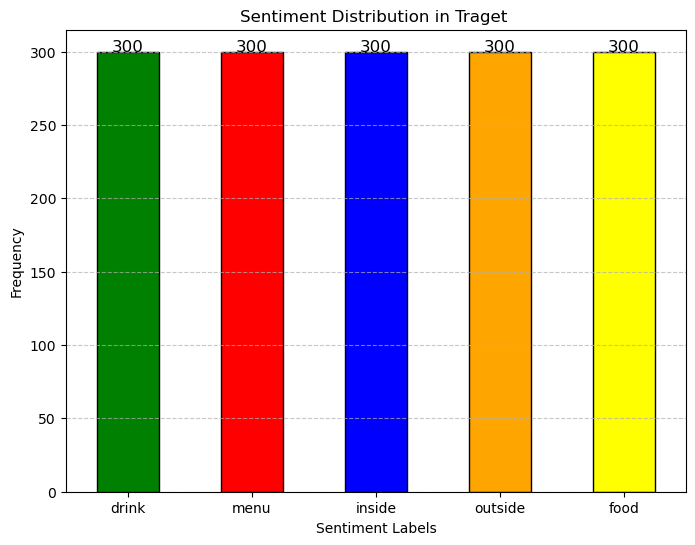

In [38]:
bar_plot(df_balanced['label'])

In [40]:
df = df_balanced

CONFIRMING THE COLUMN NAME

In [43]:
# Build a dictionary to map photo_id to the image file paths
photo_id_to_path = {}
for file in os.listdir(photos_folder):
    # Assuming the photo_id is in the file name (e.g., photo_id.jpg)
    photo_id = file.split('.')[0] # Adjust based on your file naming convention
    photo_id_to_path[photo_id] = os.path.join(photos_folder, file)

In [44]:
df.head(10)

,photo_id,label
0,QcZzmuzz-eyQlekotAF5OA,drink
1,5xIWbtcb4uIn_VW9pf8V3A,menu
2,Tmr4mNaDdf9uxM1YmaohCA,inside
3,TZgv-uQT_RiW2qNVlGE3JA,inside
4,6a7aYkFirloeJycl1lvyIA,inside
5,4v5ns1DEc7DAz0r3xyrRqw,outside
6,bdtmWbdi6PRn_M1-aHYjcw,drink
7,t61K63S-DfSbufXgZpA_Ng,outside
8,pn4AVzlHlu4PhBpyDpb2wQ,menu
9,l_rMdwgrvjm2PyHyXBcBTw,food


In [47]:
# Get the first 10 records from the dictionary
first_10_records = dict(list(photo_id_to_path.items())[:10])

# Print them
print("First 10 records:", first_10_records)

First 10 records: {'--puCF1Lauwb3k6vrVVvfQ': 'D:\\Dataset\\photos\\--puCF1Lauwb3k6vrVVvfQ.jpg', '-10Ge63S6TdapDZV5ZGJLw': 'D:\\Dataset\\photos\\-10Ge63S6TdapDZV5ZGJLw.jpg', '-15xxjJWleNHNoApS8nXZA': 'D:\\Dataset\\photos\\-15xxjJWleNHNoApS8nXZA.jpg', '-3qJQmfAxo33Dp07QzkWtA': 'D:\\Dataset\\photos\\-3qJQmfAxo33Dp07QzkWtA.jpg', '-3yDzSGRk9m7z-N6bOH0Ag': 'D:\\Dataset\\photos\\-3yDzSGRk9m7z-N6bOH0Ag.jpg', '-5bUepz7K1gaHBD3LzApbQ': 'D:\\Dataset\\photos\\-5bUepz7K1gaHBD3LzApbQ.jpg', '-6buz7yJj7J-fAEBpzfPhw': 'D:\\Dataset\\photos\\-6buz7yJj7J-fAEBpzfPhw.jpg', '-BQqi2wtRzy3TjZj3ugjuw': 'D:\\Dataset\\photos\\-BQqi2wtRzy3TjZj3ugjuw.jpg', '-BW8LZAgLYSbC9Hka7v5yA': 'D:\\Dataset\\photos\\-BW8LZAgLYSbC9Hka7v5yA.jpg', '-BzkuAu2ShaH4qd1vp6xMg': 'D:\\Dataset\\photos\\-BzkuAu2ShaH4qd1vp6xMg.jpg'}


RESIZING THE IMAGE

In [50]:
# Function to preprocess images (resize to 224x224 and normalize)
def preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        return img_array / 255.0  # Normalize the image
    except Exception as e:
        print(f"Error occurred: {e}")
        print(f"Image path: {img_path}")
        return None

# Preprocess images for each photo_id
x_images = []
y_labels = []

for _, row in df.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    
    # Get the image path based on the photo_id
    img_path = photo_id_to_path.get(photo_id)
    
    if img_path:
        # Preprocess the image
        img = preprocess_image(img_path)
        if(img is not None) :
            x_images.append(img)
            y_labels.append(label)

# Convert lists to numpy arrays for further processing
print(len(x_images))

x_images = np.array(x_images)

print(x_images)
print(y_labels)


print("\nShape of the image array: ", x_images.shape)
print("length of target: ", len(y_labels))

Error occurred: cannot identify image file <_io.BytesIO object at 0x000002821005BB50>
Image path: D:\Dataset\photos\l_rMdwgrvjm2PyHyXBcBTw.jpg
1393
[[[[0.9529412  0.9529412  0.9607843 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.69411767 0.8117647  0.9137255 ]
   [0.7607843  0.8627451  0.9529412 ]
   [0.78431374 0.88235295 0.96862745]]

  [[0.95686275 0.95686275 0.9647059 ]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.8509804  0.9372549  1.        ]
   [0.8745098  0.95686275 1.        ]
   [0.8862745  0.9607843  1.        ]]

  [[0.9607843  0.9607843  0.96862745]
   [0.9607843  0.9607843  0.96862745]
   [0.9647059  0.9647059  0.972549  ]
   ...
   [0.89411765 0.95686275 1.        ]
   [0.8980392  0.9529412  0.99607843]
   [0.89411765 0.9411765  0.9882353 ]]

  ...

  [[0.5137255  0.41960785 0.37254903]
   [0.49803922 0.39607844 0.3372549 ]
   [0.40784314 0.30980393 0.22352941]
   ...
   [0.4274509

MAPPING THE LABELS

In [52]:
label_mapping = {'food' : 0, 'inside' : 1, 'outside' : 2, 'drink' : 3, 'menu' : 4}
reverse_label_mapping = {0 : 'food',1 : 'inside',2 : 'outside',3 : 'drink',4 : 'menu'}

In [54]:
# Map the labels using the custom dictionary
y = np.array([label_mapping[label] for label in y_labels])

# Flatten the images
x = x_images.reshape(x_images.shape[0], -1)

print("Shape of the image array: ",x.shape)
print("Shape of the target array: ",y.shape)

Shape of the image array:  (1393, 150528)
Shape of the target array:  (1393,)


Making functions for evaluations

In [56]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Step 2: Convert the confusion matrix to a DataFrame for better visualization
    cm_df = pd.DataFrame(cm, index=[reverse_label_mapping[i] for i in range(len(cm))], 
                         columns=[reverse_label_mapping[i] for i in range(len(cm))])
    
    print(cm_df)
    
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", xticklabels=cm_df.columns, yticklabels=cm_df.columns)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [58]:
def plot_roc_curve(y_true, y_pred_bin):
     # Initialize LabelBinarizer
    lb = LabelBinarizer()

    # Binarize the true labels (one-hot encoding)
    y_true_bin = lb.fit_transform(y_true)   
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(y_true_bin.shape[1]):  # Iterate through all classes
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves in one plot
    plt.figure(figsize=(10, 8))
    
    # Plot ROC for each class
    for i in range(y_true_bin.shape[1]):
        label = lb.classes_[i]
        plt.plot(fpr[i], tpr[i], label=f'{reverse_label_mapping[label]} (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    # Labeling and Title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')

    # Show the plot
    plt.show()

    # Print AUC values for each class
    for i in range(y_true_bin.shape[1]):
        print(f'AUC for class {lb.classes_[i]}: {roc_auc[i]:.2f}')


SPLLITING THE DATA

In [61]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Shape of x_train: ",x_train.shape)
print("Shape of y_train: ",y_train.shape)

print("Shape of x_test: ",x_test.shape)
print("Shape of y_test: ",y_test.shape)

Shape of x_train:  (1114, 150528)
Shape of y_train:  (1114,)
Shape of x_test:  (279, 150528)
Shape of y_test:  (279,)


class_count :  1    228
4    228
0    221
3    220
2    217
Name: count, dtype: int64


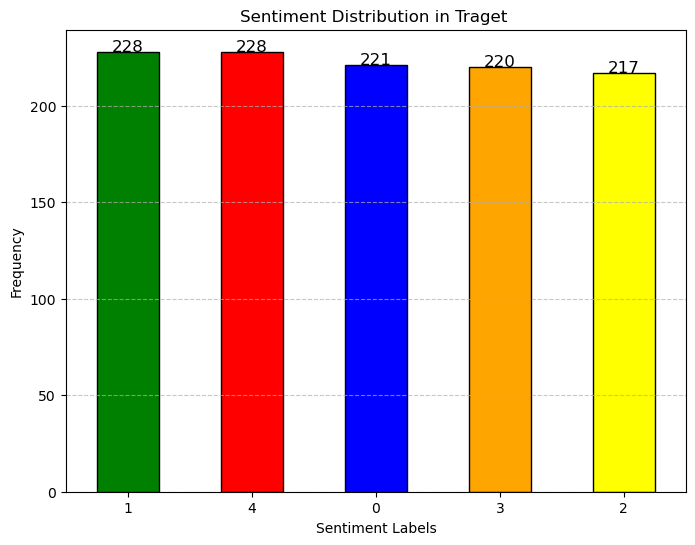

In [63]:
bar_plot(y_train)